In [19]:
import pandas as pd
df=pd.read_csv('framingham.csv')
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [21]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [37]:
import pandas as pd
import numpy as np

# Fill numeric columns with MEDIAN
df['cigsPerDay'] = df['cigsPerDay'].fillna(df['cigsPerDay'].median())
df['totChol'] = df['totChol'].fillna(df['totChol'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['heartRate'] = df['heartRate'].fillna(df['heartRate'].median())
df['glucose'] = df['glucose'].fillna(df['glucose'].median())

# Fill categorical/binary columns with MODE
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['BPMeds'] = df['BPMeds'].fillna(df['BPMeds'].mode()[0])

# Check again
print(df.isnull().sum())

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [23]:
df.duplicated().sum()

0

In [24]:
df = df.drop_duplicates()

In [25]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression (Balanced)
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Decision Tree (Balanced)
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

# Random Forest (Balanced)
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# KNN (No class_weight available)
knn_model = KNeighborsClassifier()

# Train models
log_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

C:\Users\taran\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KNeighborsClassifier()

In [29]:
y_pred_log = log_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)

In [30]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

Logistic Regression Accuracy: 0.6580188679245284
Decision Tree Accuracy: 0.7700471698113207
Random Forest Accuracy: 0.8584905660377359
KNN Accuracy: 0.8443396226415094


In [31]:
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_log))

print("===== Decision Tree =====")
print(classification_report(y_test, y_pred_dt))

print("===== Random Forest =====")
print(classification_report(y_test, y_pred_rf))

print("===== KNN =====")
print(classification_report(y_test, y_pred_knn))

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.91      0.66      0.77       725
           1       0.24      0.62      0.34       123

    accuracy                           0.66       848
   macro avg       0.57      0.64      0.56       848
weighted avg       0.81      0.66      0.71       848

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       725
           1       0.20      0.20      0.20       123

    accuracy                           0.77       848
   macro avg       0.53      0.53      0.53       848
weighted avg       0.77      0.77      0.77       848

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       725
           1       0.71      0.04      0.08       123

    accuracy                           0.86       848
   macro avg       0.79      0.52      0.50 

            Feature  Importance
1               age    0.151127
10            sysBP    0.134296
12              BMI    0.119580
9           totChol    0.118814
11            diaBP    0.112103
14          glucose    0.107460
13        heartRate    0.093574
4        cigsPerDay    0.053075
2         education    0.035462
7      prevalentHyp    0.024931
0              male    0.021452
3     currentSmoker    0.013540
8          diabetes    0.007142
5            BPMeds    0.005634
6   prevalentStroke    0.001812


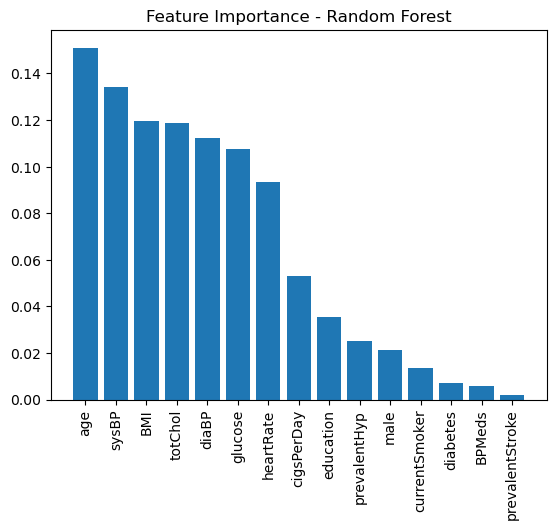

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

print(feature_importance_df)

# Plot
plt.figure()
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance - Random Forest")
plt.show()

In [39]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score

models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "KNN": knn_model
}

for name, model in models.items():
    print("======================================")
    print(f"{name}")
    print("======================================")
    
    y_pred = model.predict(X_test)
    
    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    # Recall for class 1 (High Risk)
    recall = recall_score(y_test, y_pred)
    print("Recall (High Risk class):", recall)
    
    # Full Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\n\n")

Logistic Regression
Confusion Matrix:
[[482 243]
 [ 47  76]]
Recall (High Risk class): 0.6178861788617886

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.66      0.77       725
           1       0.24      0.62      0.34       123

    accuracy                           0.66       848
   macro avg       0.57      0.64      0.56       848
weighted avg       0.81      0.66      0.71       848




Decision Tree
Confusion Matrix:
[[628  97]
 [ 98  25]]
Recall (High Risk class): 0.2032520325203252

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       725
           1       0.20      0.20      0.20       123

    accuracy                           0.77       848
   macro avg       0.53      0.53      0.53       848
weighted avg       0.77      0.77      0.77       848




Random Forest
Confusion Matrix:
[[723   2]
 [118   5]]
Recall (High Risk class): 0.040

In [40]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score

print("======================================")
print("Logistic Regression (Threshold = 0.4)")
print("======================================")

# Get probabilities
y_prob = log_model.predict_proba(X_test)[:, 1]

# Change threshold (default is 0.5)
y_pred_custom = (y_prob > 0.4).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("Recall (High Risk class):", recall_score(y_test, y_pred_custom))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

Logistic Regression (Threshold = 0.4)
Confusion Matrix:
[[369 356]
 [ 26  97]]
Recall (High Risk class): 0.7886178861788617

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.51      0.66       725
           1       0.21      0.79      0.34       123

    accuracy                           0.55       848
   macro avg       0.57      0.65      0.50       848
weighted avg       0.83      0.55      0.61       848



In [41]:
import pickle

# Create dictionary containing model and threshold
final_object = {
    "model": log_model,
    "threshold": 0.4
}

# Save to single pickle file
with open("heart_disease_pipeline.pkl", "wb") as f:
    pickle.dump(final_object, f)

print("Model and threshold (0.4) saved successfully!")

Model and threshold (0.4) saved successfully!


In [42]:
import pickle
import numpy as np

# Load the saved file
with open("heart_disease_pipeline.pkl", "rb") as f:
    saved = pickle.load(f)

# Extract model and threshold
model = saved["model"]
threshold = saved["threshold"]

print("Loaded threshold:", threshold)

Loaded threshold: 0.4


In [45]:
print(df.columns)

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')
